# Futures Positioning: CFTC Commitment of Traders Analysis

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: See Section 4.3 for cross-asset fundamentals concepts

## Purpose

This notebook demonstrates how to access CFTC Commitment of Traders (COT) data
for tracking institutional positioning in futures markets. COT reports provide
weekly snapshots of trader positioning, offering valuable sentiment signals for
futures trading strategies and contrarian indicators.

## Learning Objectives

After completing this notebook, you will be able to:
- Understand COT report structure and trader categories
- Fetch COT data for futures products using ml4t-data
- Calculate net positioning and z-scores
- Identify extreme positioning for contrarian signals
- Combine COT with price data for strategy features

## Cross-References

- **Upstream**: `data/futures/positioning/cot_download.py` (CFTC COT reports, weekly, free)
- **Downstream**: Chapter 8 `futures_features.py`, Chapter 16 futures strategies
- **Related**: `macro_data_alignment.py` (macro timing signals)

## Why COT Data Matters

COT data is **free** and provides unique insight into:
- **Institutional positioning**: What are hedge funds/asset managers doing?
- **Commercial hedging**: Are producers/consumers unusual in their hedging?
- **Crowd behavior**: Are speculators too extreme (contrarian signal)?

---

In [1]:
"""Futures Positioning: CFTC Commitment of Traders Analysis — track institutional positioning for contrarian signals."""

import warnings

warnings.filterwarnings("ignore")


# Visualization
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI

In [3]:
def keep_largest_contract(df: pl.DataFrame) -> pl.DataFrame:
    """Drop duplicate (product, report_date) rows.

    The CFTC publishes both 'Futures Only' and 'Combined Futures+Options'
    panels for each product; the bulk downloader writes both into the
    same parquet, leaving two rows per report_date. The combined panel
    has materially larger open interest and is the canonical series used
    for positioning analysis — keep that one.
    """
    return (
        df.sort(["product", "report_date", "open_interest"], descending=[False, False, True])
        .unique(subset=["product", "report_date"], keep="first")
        .sort("report_date")
    )

---

## Section 1: Understanding COT Reports

The CFTC publishes weekly COT reports, showing positions as of Tuesday. Reports are
generally released Friday at **3:30 PM ET** (with holiday delays). For daily-bar
backtests, a conservative approach is to treat the information as usable from the
next trading day (+6 calendar days from Tuesday).

There are two main report formats relevant for trading:

### Report Types

| Report | Coverage | Key Categories |
|--------|----------|----------------|
| **TFF** (Traders in Financial Futures) | Financial futures | Dealers, Asset Managers, Leveraged Money |
| **Disaggregated** | Commodity futures | Commercials, Managed Money, Swap Dealers |

### Trader Categories

**Financial Futures (TFF):**
- **Dealers/Intermediaries**: Banks, swap dealers (market makers)
- **Asset Managers**: Pension funds, mutual funds (institutional)
- **Leveraged Money**: Hedge funds, CTAs (speculators)
- **Other Reportables**: Other large traders
- **Non-Reportables**: Small traders (retail)

**Commodity Futures (Disaggregated):**
- **Commercials (Producer/Merchant)**: Physical commodity hedgers
- **Swap Dealers**: Financial intermediaries
- **Managed Money**: Hedge funds, CTAs
- **Other Reportables**: Other large traders

### Key Insight

**Commercials** hedge their physical exposure (informed), while **Speculators**
(Leveraged Money, Managed Money) bet on direction. Extreme speculator positioning
often precedes reversals.

---

## Section 2: ml4t-data COT Module

In [4]:
from ml4t.data.cot import PRODUCT_MAPPINGS

from data.futures.loader import load_cot

print(f"Supported products: {len(PRODUCT_MAPPINGS)}")

Supported products: 36


In [5]:
categories = {
    "Equity Index": ["ES", "NQ", "RTY", "YM"],
    "Currency": ["6E", "6J", "6B", "6C", "6A"],
    "Interest Rate": ["ZN", "ZB", "ZF", "ZT"],
    "Energy": ["CL", "NG", "RB", "HO"],
    "Metals": ["GC", "SI", "HG", "PL"],
    "Agricultural": ["ZC", "ZW", "ZS", "ZM", "ZL"],
    "Crypto": ["BTC", "ETH"],
    "Volatility": ["VX"],
}

for category, products in categories.items():
    available = [p for p in products if p in PRODUCT_MAPPINGS]
    print(f"{category}:")
    for p in available:
        info = PRODUCT_MAPPINGS[p]
        print(f"  {p:5}  {info.description}  ({info.report_type[:4]})")
    print()

Equity Index:
  ES     E-mini S&P 500  (trad)
  NQ     E-mini NASDAQ-100  (trad)
  RTY    E-mini Russell 2000  (trad)
  YM     E-mini Dow Jones  (trad)

Currency:
  6E     Euro FX  (trad)
  6J     Japanese Yen  (trad)
  6B     British Pound  (trad)
  6C     Canadian Dollar  (trad)
  6A     Australian Dollar  (trad)

Interest Rate:
  ZN     10-Year T-Note  (trad)
  ZB     30-Year T-Bond  (trad)
  ZF     5-Year T-Note  (trad)
  ZT     2-Year T-Note  (trad)

Energy:
  CL     WTI Crude Oil  (disa)
  NG     Natural Gas  (disa)
  RB     RBOB Gasoline  (disa)
  HO     Heating Oil  (disa)

Metals:
  GC     Gold  (disa)
  SI     Silver  (disa)
  HG     Copper  (disa)
  PL     Platinum  (disa)

Agricultural:
  ZC     Corn  (disa)
  ZW     Wheat (SRW)  (disa)
  ZS     Soybeans  (disa)
  ZM     Soybean Meal  (disa)
  ZL     Soybean Oil  (disa)

Crypto:
  BTC    Bitcoin  (trad)
  ETH    Ether  (trad)

Volatility:
  VX     VIX Futures  (trad)



---

## Section 3: Loading COT Data

COT data is downloaded by ``data/futures/positioning/cot_download.py`` into
``$ML4T_DATA_PATH/futures/positioning/cot/{PRODUCT}.parquet`` and loaded here via
``load_cot()``.

In [6]:
es_cot = keep_largest_contract(
    load_cot(products=["ES"], start_date="2020-01-01", end_date="2024-12-31")
)

print(f"Shape: {es_cot.shape}")
print(f"Date range: {es_cot['report_date'].min()} to {es_cot['report_date'].max()}")
print(f"Columns: {es_cot.columns}")
es_cot.head()

Shape: (261, 29)
Date range: 2020-01-07 to 2024-12-31
Columns: ['report_date', 'open_interest', 'dealer_long', 'dealer_short', 'dealer_spread', 'asset_mgr_long', 'asset_mgr_short', 'asset_mgr_spread', 'lev_money_long', 'lev_money_short', 'lev_money_spread', 'other_rept_long', 'other_rept_short', 'other_rept_spread', 'nonrept_long', 'nonrept_short', 'oi_change', 'dealer_long_change', 'dealer_short_change', 'asset_mgr_long_change', 'asset_mgr_short_change', 'lev_money_long_change', 'lev_money_short_change', 'product', 'report_type', 'dealer_net', 'asset_mgr_net', 'lev_money_net', 'nonrept_net']


report_date,open_interest,dealer_long,dealer_short,dealer_spread,asset_mgr_long,asset_mgr_short,asset_mgr_spread,lev_money_long,lev_money_short,lev_money_spread,other_rept_long,other_rept_short,other_rept_spread,nonrept_long,nonrept_short,oi_change,dealer_long_change,dealer_short_change,asset_mgr_long_change,asset_mgr_short_change,lev_money_long_change,lev_money_short_change,product,report_type,dealer_net,asset_mgr_net,lev_money_net,nonrept_net
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64
2020-01-07,2709583,211413,842691,52239,1517347,485703,226936,306634,496926,33576,89775,298006,4102,267561,269404,""" -10701""",""" -4548""",""" -30078""",""" -1034""",""" -4807""",""" 13285""",""" 14246""","""ES""","""traders_in_financial_futures_f…",-631278,1031644,-190292,-1843
2020-01-14,2703002,167771,872490,72226,1564147,470129,219094,263419,499376,41556,90840,272946,3962,279987,251223,""" -6581""",""" -43642""",""" 29799""",""" 46800""",""" -15574""",""" -43215""",""" 2450""","""ES""","""traders_in_financial_futures_f…",-704719,1094018,-235957,28764
2020-01-21,2772927,184098,904477,78103,1581681,480609,212070,277495,535211,45645,103631,266718,5018,285186,245076,""" 69925""",""" 16327""",""" 31987""",""" 17534""",""" 10480""",""" 14076""",""" 35835""","""ES""","""traders_in_financial_futures_f…",-720379,1101072,-257716,40110
2020-01-28,2741743,190418,943378,76478,1539295,488504,224130,274379,503260,34630,110512,203094,4364,287537,263905,""" -31184""",""" 6320""",""" 38901""",""" -42386""",""" 7895""",""" -3116""",""" -31951""","""ES""","""traders_in_financial_futures_f…",-752960,1050791,-228881,23632
2020-02-04,2697443,164104,948131,86123,1517375,459615,229782,260162,479644,34344,103796,192906,6296,295461,260602,""" -44300""",""" -26314""",""" 4753""",""" -21920""",""" -28889""",""" -14217""",""" -23616""","""ES""","""traders_in_financial_futures_f…",-784027,1057760,-219482,34859


### COT Data Columns

| Column | Description | Signal |
|--------|-------------|--------|
| `open_interest` | Total contracts outstanding | Liquidity, conviction |
| `lev_money_long` | Hedge fund long positions | Speculator sentiment |
| `lev_money_short` | Hedge fund short positions | Speculator sentiment |
| `lev_money_net` | Long - Short | Net speculator positioning |
| `asset_mgr_net` | Asset manager net | Institutional positioning |
| `dealer_net` | Dealer net | Market maker flow |

In [7]:
cl_cot = keep_largest_contract(
    load_cot(products=["CL"], start_date="2020-01-01", end_date="2024-12-31")
)
# Disaggregated reports use `managed_money_*` instead of `lev_money_*`;
# standardize for downstream analysis.
cl_cot = cl_cot.with_columns(pl.col("managed_money_net").alias("lev_money_net"))

print(f"Shape: {cl_cot.shape}")
print(f"Columns (note different categories): {cl_cot.columns}")
cl_cot.head()

Shape: (261, 26)
Columns (note different categories): ['report_date', 'open_interest', 'commercial_long', 'commercial_short', 'swap_long', 'swap_short', 'swap_spread', 'managed_money_long', 'managed_money_short', 'managed_money_spread', 'other_rept_long', 'other_rept_short', 'other_rept_spread', 'nonrept_long', 'nonrept_short', 'oi_change', 'commercial_long_change', 'commercial_short_change', 'managed_money_long_change', 'managed_money_short_change', 'product', 'report_type', 'commercial_net', 'managed_money_net', 'nonrept_net', 'lev_money_net']


report_date,open_interest,commercial_long,commercial_short,swap_long,swap_short,swap_spread,managed_money_long,managed_money_short,managed_money_spread,other_rept_long,other_rept_short,other_rept_spread,nonrept_long,nonrept_short,oi_change,commercial_long_change,commercial_short_change,managed_money_long_change,managed_money_short_change,product,report_type,commercial_net,managed_money_net,nonrept_net,lev_money_net
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,i64,i64,i64,i64
2020-01-07,2244930,427802,454860,138350,709217,163954,340235,29708,551407,298774,42029,225524,98884,68231,""" 99363""",""" 19988""",""" 22602""",""" 8873""",""" -876""","""CL""","""disaggregated_fut""",-27058,310527,30653,310527
2020-01-14,2215893,394095,395926,138293,700794,155052,285931,48882,603210,324513,31250,222744,92055,58035,""" -29037""",""" -33707""",""" -58934""",""" -54304""",""" 19174""","""CL""","""disaggregated_fut""",-1831,237049,34020,237049
2020-01-21,2146832,372657,369076,137850,690907,149484,291872,48176,580595,307356,30484,224674,82344,53436,""" -69061""",""" -21438""",""" -26850""",""" 5941""",""" -706""","""CL""","""disaggregated_fut""",3581,243696,28908,243696
2020-01-28,2172019,363255,354371,139223,634242,174783,264171,85712,594978,324084,40781,225605,85920,61547,""" 25187""",""" -9402""",""" -14705""",""" -27701""",""" 37536""","""CL""","""disaggregated_fut""",8884,178459,24373,178459
2020-02-04,2271741,445078,420616,141180,590768,198733,249960,123251,570742,326957,56292,247095,91996,64244,""" 99722""",""" 81823""",""" 66245""",""" -14211""",""" 37539""","""CL""","""disaggregated_fut""",24462,126709,27752,126709


---

## Section 4: Positioning Analysis

Calculate z-scores to identify extreme positioning.

In [8]:
def calculate_positioning_zscore(
    df: pl.DataFrame,
    net_column: str,
    window: int = 52,  # 1 year of weekly data
) -> pl.DataFrame:
    """
    Calculate z-score of net positioning.

    Z-scores help identify when positioning is extreme relative to history:
    - Z > 2: Very bullish (potentially overbought)
    - Z < -2: Very bearish (potentially oversold)
    """
    return df.with_columns(
        [
            pl.col(net_column).rolling_mean(window).alias(f"{net_column}_mean"),
            pl.col(net_column).rolling_std(window).alias(f"{net_column}_std"),
        ]
    ).with_columns(
        [
            # Z-score with guard against zero std
            pl.when(pl.col(f"{net_column}_std") > 0)
            .then((pl.col(net_column) - pl.col(f"{net_column}_mean")) / pl.col(f"{net_column}_std"))
            .otherwise(0.0)
            .alias(f"{net_column}_zscore"),
        ]
    )

In [9]:
es_with_zscore = calculate_positioning_zscore(es_cot, "lev_money_net")

extreme_long = es_with_zscore.filter(pl.col("lev_money_net_zscore") > 2)
extreme_short = es_with_zscore.filter(pl.col("lev_money_net_zscore") < -2)

print(f"Extreme Long readings (z > 2):  {len(extreme_long)}")
print(f"Extreme Short readings (z < -2): {len(extreme_short)}")
es_with_zscore.select(["report_date", "lev_money_net", "lev_money_net_zscore"]).tail(10)

Extreme Long readings (z > 2):  11
Extreme Short readings (z < -2): 8


report_date,lev_money_net,lev_money_net_zscore
date,i64,f64
2024-10-29,-289253,0.601611
2024-11-05,-189359,2.015941
2024-11-12,-274313,0.768468
2024-11-19,-251531,1.07149
2024-11-26,-304923,0.298866
2024-12-03,-359412,-0.482887
2024-12-10,-296652,0.400647
2024-12-17,-256167,0.96095
2024-12-24,-331703,-0.123874


---

## Section 5: Visualizing Positioning

In [10]:
# Visualize leveraged money positioning
es_pd = es_with_zscore.to_pandas()

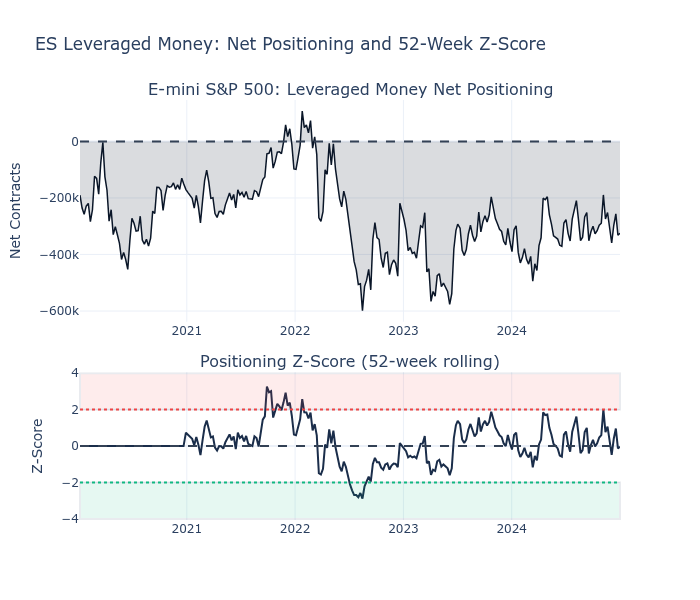

In [11]:
# Build both panels in a SINGLE cell (feedback_split_cell_figure_bug):
# splitting the figure across cells produced a top-panel-only intermediate.
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        "E-mini S&P 500: Leveraged Money Net Positioning",
        "Positioning Z-Score (52-week rolling)",
    ),
    row_heights=[0.6, 0.4],
    vertical_spacing=0.12,
)

# Net positioning
fig.add_trace(
    go.Scatter(
        x=es_pd["report_date"],
        y=es_pd["lev_money_net"],
        mode="lines",
        name="Lev Money Net",
        line=dict(color=COLORS["blue"], width=1.5),
        fill="tozeroy",
        fillcolor="rgba(10, 22, 40, 0.15)",
    ),
    row=1,
    col=1,
)

# Zero line
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

# Z-score with color bands
fig.add_trace(
    go.Scatter(
        x=es_pd["report_date"],
        y=es_pd["lev_money_net_zscore"],
        mode="lines",
        name="Z-Score",
        line=dict(color=COLORS["slate"], width=2),
    ),
    row=2,
    col=1,
)

# Add shaded extreme zones
fig.add_hrect(y0=2, y1=4, fillcolor=COLORS["negative"], opacity=0.1, row=2, col=1)
fig.add_hrect(y0=-4, y1=-2, fillcolor=COLORS["positive"], opacity=0.1, row=2, col=1)

# Extreme thresholds
fig.add_hline(y=2, line_dash="dot", line_color=COLORS["negative"], row=2, col=1)
fig.add_hline(y=-2, line_dash="dot", line_color=COLORS["positive"], row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

fig.update_layout(
    height=600,
    title="ES Leveraged Money: Net Positioning and 52-Week Z-Score",
    template="plotly_white",
    showlegend=False,
)
fig.update_yaxes(title_text="Net Contracts", row=1, col=1)
fig.update_yaxes(title_text="Z-Score", row=2, col=1)
fig.show()

---

## Section 6: COT-Based Trading Signals

COT data can generate several types of signals:

### Signal Types

| Signal | Description | Typical Use |
|--------|-------------|-------------|
| **Contrarian** | Fade extreme positioning | Z-score > 2 = sell signal |
| **Momentum** | Follow smart money | Commercials positioning |
| **Divergence** | Commercial vs Speculator | When they disagree |
| **Extreme Change** | Rapid positioning shift | Large weekly change |

In [12]:
def add_pit_available_date(df: pl.DataFrame, report_date_col: str = "report_date") -> pl.DataFrame:
    """
    Add a conservative point-in-time availability date for COT.

    COT positions are as of Tuesday and are generally released Friday at 3:30 PM ET,
    with holiday delays. For daily-bar backtests, a conservative approximation is to
    treat the data as available on the next business day after the release week.

    If you model intraday timestamps, store a datetime availability timestamp instead.

    Args:
        df: DataFrame with report_date column
        report_date_col: Name of the report date column

    Returns:
        DataFrame with available_date column added
    """
    return df.with_columns(
        # Conservative: Tuesday -> next Monday (+6 days) ensures we never use Friday same-day.
        # Adjust this policy based on your backtest timestamp resolution.
        (pl.col(report_date_col) + pl.duration(days=6)).alias("available_date")
    )

### Generate COT-Based Signals
Compute contrarian and large-change signals from speculator positioning z-scores.

In [13]:
def generate_cot_signals(df: pl.DataFrame, speculator_net: str = "lev_money_net") -> pl.DataFrame:
    """
    Generate COT-based trading signals.

    Note: For backtesting, use available_date (not report_date) to avoid lookahead bias.
    """
    # Add PIT-correct available_date
    df = add_pit_available_date(df)

    # Calculate z-score
    df = calculate_positioning_zscore(df, speculator_net)

    # Generate signals
    return df.with_columns(
        [
            # Contrarian signal: extreme positioning suggests reversal
            pl.when(pl.col(f"{speculator_net}_zscore") > 2)
            .then(pl.lit(-1))
            .when(pl.col(f"{speculator_net}_zscore") < -2)
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
            .alias("contrarian_signal"),
            # Week-over-week positioning change
            pl.col(speculator_net).diff().alias(f"{speculator_net}_change"),
        ]
    ).with_columns(
        [
            # Large change signal (>1 std dev of changes)
            pl.when(
                pl.col(f"{speculator_net}_change")
                > pl.col(f"{speculator_net}_change").rolling_std(26)
            )
            .then(pl.lit(1))
            .when(
                pl.col(f"{speculator_net}_change")
                < -pl.col(f"{speculator_net}_change").rolling_std(26)
            )
            .then(pl.lit(-1))
            .otherwise(pl.lit(0))
            .alias("large_change_signal"),
        ]
    )

In [14]:
es_signals = generate_cot_signals(es_cot)
contrarian_counts = es_signals.group_by("contrarian_signal").len().sort("contrarian_signal")
contrarian_counts

contrarian_signal,len
i32,u32
-1,11
0,242
1,8


Recent signals — for backtesting always join on `available_date` (+6 days), not the
Tuesday `report_date`, so signals never use information published after the bar.

In [15]:
es_signals.select(
    [
        "report_date",
        "available_date",
        "lev_money_net",
        "lev_money_net_zscore",
        "contrarian_signal",
        "large_change_signal",
    ]
).tail(10)

report_date,available_date,lev_money_net,lev_money_net_zscore,contrarian_signal,large_change_signal
date,date,i64,f64,i32,i32
2024-10-29,2024-11-04,-289253,0.601611,0,0
2024-11-05,2024-11-11,-189359,2.015941,-1,1
2024-11-12,2024-11-18,-274313,0.768468,0,-1
2024-11-19,2024-11-25,-251531,1.07149,0,0
2024-11-26,2024-12-02,-304923,0.298866,0,-1
2024-12-03,2024-12-09,-359412,-0.482887,0,-1
2024-12-10,2024-12-16,-296652,0.400647,0,1
2024-12-17,2024-12-23,-256167,0.96095,0,0
2024-12-24,2024-12-30,-331703,-0.123874,0,-1


---

## Section 6.1: Multi-Product Positioning Comparison

Comparing positioning across products reveals cross-asset sentiment.

In [16]:
gc_cot = keep_largest_contract(
    load_cot(products=["GC"], start_date="2020-01-01", end_date="2024-12-31")
)
gc_cot = gc_cot.with_columns(pl.col("managed_money_net").alias("lev_money_net"))
print(f"Shape: {gc_cot.shape}")

# Calculate z-scores for all products
es_z = calculate_positioning_zscore(es_cot, "lev_money_net")
cl_z = calculate_positioning_zscore(cl_cot, "lev_money_net")
gc_z = calculate_positioning_zscore(gc_cot, "lev_money_net")

Shape: (261, 26)


In [17]:
# Create multi-product comparison
fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=(
        "E-mini S&P 500 (ES) - Equity Index",
        "Crude Oil (CL) - Energy",
        "Gold (GC) - Precious Metals",
    ),
    vertical_spacing=0.08,
    shared_xaxes=True,
)

for i, (df, name, color) in enumerate(
    [
        (es_z.to_pandas(), "ES", COLORS["blue"]),
        (cl_z.to_pandas(), "CL", COLORS["amber"]),
        (gc_z.to_pandas(), "GC", COLORS["slate"]),
    ],
    1,
):
    # Z-score line
    fig.add_trace(
        go.Scatter(
            x=df["report_date"],
            y=df["lev_money_net_zscore"],
            mode="lines",
            name=f"{name} Z-Score",
            line=dict(color=color, width=1.5),
        ),
        row=i,
        col=1,
    )

    # Extreme bands
    fig.add_hrect(y0=2, y1=4, fillcolor=COLORS["negative"], opacity=0.1, row=i, col=1)
    fig.add_hrect(y0=-4, y1=-2, fillcolor=COLORS["positive"], opacity=0.1, row=i, col=1)
    fig.add_hline(y=2, line_dash="dot", line_color=COLORS["negative"], opacity=0.5, row=i, col=1)
    fig.add_hline(y=-2, line_dash="dot", line_color=COLORS["positive"], opacity=0.5, row=i, col=1)
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], opacity=0.5, row=i, col=1)

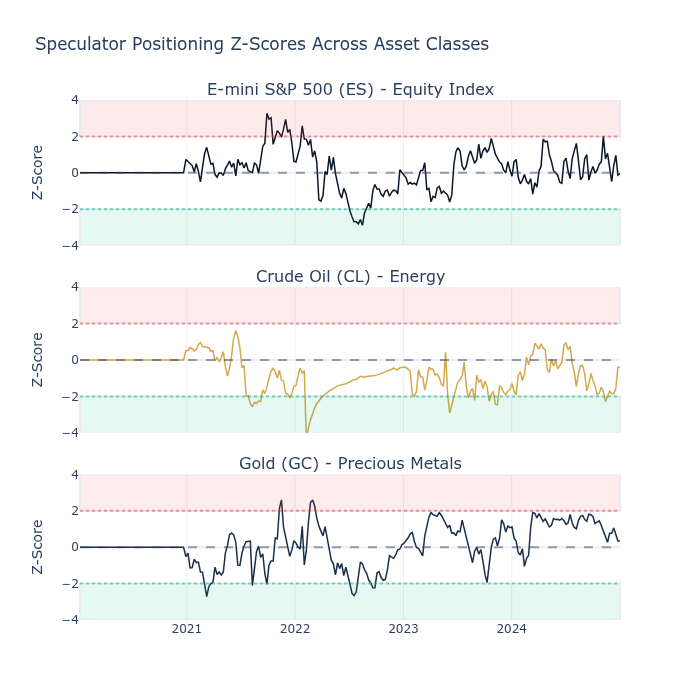

In [18]:
fig.update_layout(
    height=700,
    title="Speculator Positioning Z-Scores Across Asset Classes",
    template="plotly_white",
    showlegend=False,
)
fig.update_yaxes(title_text="Z-Score", range=[-4, 4])
fig.show()

In [19]:
latest = es_cot.sort("report_date").tail(1)
print(f"Latest Report: {latest['report_date'][0]}")
print("Net Positions by Trader Category:")
print(f"  Leveraged Money (Hedge Funds):  {latest['lev_money_net'][0]:>12,}")
print(f"  Asset Managers (Institutions):  {latest['asset_mgr_net'][0]:>12,}")
print(f"  Dealers (Market Makers):        {latest['dealer_net'][0]:>12,}")

Latest Report: 2024-12-31
Net Positions by Trader Category:
  Leveraged Money (Hedge Funds):      -324,607
  Asset Managers (Institutions):       984,063
  Dealers (Market Makers):            -810,986


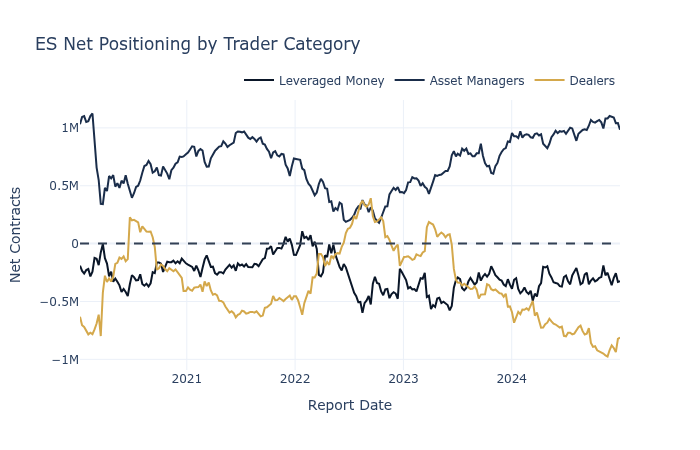

In [20]:
# Visualize trader categories over time
es_pd = es_cot.to_pandas()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=es_pd["report_date"],
        y=es_pd["lev_money_net"],
        mode="lines",
        name="Leveraged Money",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=es_pd["report_date"],
        y=es_pd["asset_mgr_net"],
        mode="lines",
        name="Asset Managers",
        line=dict(color=COLORS["slate"], width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=es_pd["report_date"],
        y=es_pd["dealer_net"],
        mode="lines",
        name="Dealers",
        line=dict(color=COLORS["amber"], width=2),
    )
)

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])

fig.update_layout(
    height=450,
    title="ES Net Positioning by Trader Category",
    template="plotly_white",
    xaxis_title="Report Date",
    yaxis_title="Net Contracts",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

**Key Observations:**
- **Leveraged Money** (hedge funds) shows the most volatility and tends to be trend-following
- **Asset Managers** are smoother, reflecting longer-term institutional allocations
- **Dealers** often take the opposite side (market making), providing liquidity
- When all categories align, it can signal crowded positioning

---

## Section 7: ml4t-data Feature Generation

The ml4t-data library provides utilities to combine COT with price data.

In [21]:
sample_features = es_signals.select(
    [
        "report_date",
        "available_date",
        "lev_money_net_zscore",
        "contrarian_signal",
        "large_change_signal",
    ]
).with_columns(
    [
        # Additional features
        pl.col("lev_money_net_zscore").shift(1).alias("zscore_lag1"),
        (pl.col("lev_money_net_zscore") - pl.col("lev_money_net_zscore").shift(1)).alias(
            "zscore_momentum"
        ),
    ]
)
sample_features.tail(10)

report_date,available_date,lev_money_net_zscore,contrarian_signal,large_change_signal,zscore_lag1,zscore_momentum
date,date,f64,i32,i32,f64,f64
2024-10-29,2024-11-04,0.601611,0,0,0.470741,0.13087
2024-11-05,2024-11-11,2.015941,-1,1,0.601611,1.41433
2024-11-12,2024-11-18,0.768468,0,-1,2.015941,-1.247473
2024-11-19,2024-11-25,1.07149,0,0,0.768468,0.303022
2024-11-26,2024-12-02,0.298866,0,-1,1.07149,-0.772624
2024-12-03,2024-12-09,-0.482887,0,-1,0.298866,-0.781753
2024-12-10,2024-12-16,0.400647,0,1,-0.482887,0.883534
2024-12-17,2024-12-23,0.96095,0,0,0.400647,0.560303
2024-12-24,2024-12-30,-0.123874,0,-1,0.96095,-1.084824


---

## Section 8: Summary

### Key Takeaways

1. **COT data is free** and provides unique institutional positioning insight
2. **Two report types**: TFF (financial) and Disaggregated (commodities)
3. **Z-scores** identify extreme positioning for contrarian signals
4. **Commercials vs Speculators**: Track the "smart money"
5. **Release lag**: Report date is Tuesday, released Friday 3:30 PM - use +6 day lag for daily backtests!

### Using CoT in the book

Download (one-time, writes per-product parquets to ``$ML4T_DATA_PATH/futures/positioning/cot/``):

```bash
python data/futures/positioning/cot_download.py                         # all products, 2020–current
python data/futures/positioning/cot_download.py --products ES,CL,GC,ZN  # subset
python data/futures/positioning/cot_download.py --start-year 2010       # longer history
```

Load in a notebook:

```python
from data.futures.loader import load_cot

es_cot = load_cot(products=["ES"], start_date="2020-01-01", end_date="2024-12-31")
all_cot = load_cot()  # everything available locally
```

### Integration with Book

- **Chapter 8**: COT as sentiment feature for financial feature engineering
- **Chapter 16**: Futures strategy using positioning signals
- **Chapter 19**: COT in portfolio risk monitoring